Below is a practical, end-to-end recipe you can adapt to your own cutting-test data. I assume your raw table looks roughly like this:

| feed_mm_min | spindle_rpm | depth_ap_mm | edges_z | ae_pct |
|-------------|-------------|-------------|---------|--------|
| 1200        | 6500        | 1.0         | 2       | 25     |
| ...         | ...         | ...         | ...     | 95     |

1. Decide: classification vs regression
Because ae only takes four discrete values (25 / 50 / 75 / 95 %), a 4-class classifier is simplest and lets you monitor class-level performance (confusion matrix).
If in a later study you allow any ae between 0 – 100 %, switch to a regression loss (e.g. MSE).

2. Python environment
bash
Copiar
Editar
pip install pandas scikit-learn scikeras[tensorflow] matplotlib seaborn
scikeras is a thin wrapper that lets you treat a Keras model as if it were an sklearn estimator—handy for pipelines and tuning.

3. Pre-processing pipeline
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scikeras.wrappers import KerasClassifier
from tensorflow import keras



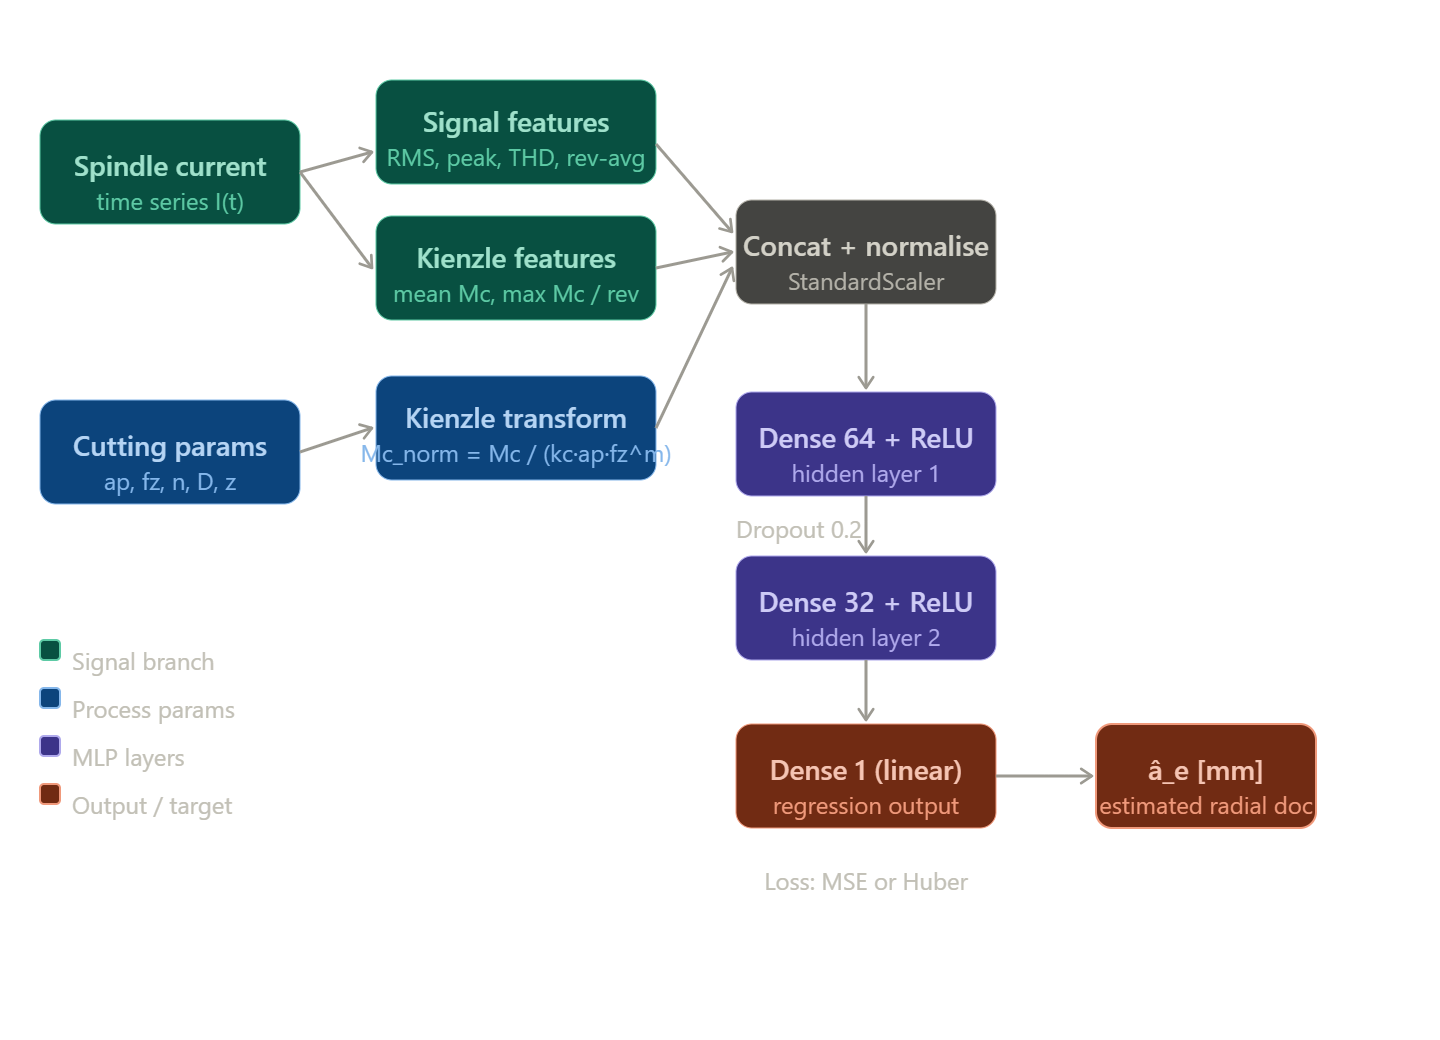

Step 1 — Install and import dependencies

In [1]:
# import relevant packages

# In a cell at the top of the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
# read in a info file with all relevant process data
## tkinter not working in *.jpynb
#import tkinter as tk
#from tkinter import filedialog
#import pandas as pd

#root = tk.Tk()
#root.withdraw()  # hide the empty root window

#file_path = filedialog.askopenfilename(
#    title="Select Excel file",
#    filetypes=[("Excel files", "*.xlsx *.xls"), ("All files", "*.*")]
#)
#root.destroy()

## Alternative
from ipyfilechooser import FileChooser
data_file_path = "G:\Mi unidad\Exchange\MscCD\Measurements_CutOpt"
data_info_file = "Experiment_C4240.xlsx"
fc = FileChooser(data_file_path )   # starting directory
fc.filter_pattern = ["*.xlsx", "*.xls"]
display(fc)
##
complete_info_file_path =   data_file_path + '\\' + data_info_file
print(complete_info_file_path)


FileChooser(path='G:\Mi unidad\Exchange\MscCD\Measurements_CutOpt', filename='', title='', show_hidden=False, …

G:\Mi unidad\Exchange\MscCD\Measurements_CutOpt\Experiment_C4240.xlsx


In [3]:
import pandas as pd

df_info = pd.read_excel(complete_info_file_path)   # fc.selected holds the full path
print(f"Loaded: {data_info_file}")
df_info.head()
##

df_info = pd.read_excel(complete_info_file_path)
print(f"Loaded: {complete_info_file_path}")
df_info.head()

Loaded: Experiment_C4240.xlsx
Loaded: G:\Mi unidad\Exchange\MscCD\Measurements_CutOpt\Experiment_C4240.xlsx


,Ae (mm),Ap (mm),f (mm/min),N (rpm),R (mm),Z,fz,Vc,SinuTraceFile (*.csv)
0,40,1.0,632.00,2108.0,20,2,0.149905,264.899093,Trace_0623_164010.csv
1,38,1.0,632.00,2108.0,20,2,0.149905,264.899093,Trace_0623_164120.csv
2,32,1.0,632.00,2108.0,20,2,0.149905,264.899093,Trace_0623_164227.csv
3,26,1.0,632.00,2108.0,20,2,0.149905,264.899093,Trace_0623_164408.csv
4,40,1.0,505.92,1686.4,20,2,0.150000,211.919274,Trace_0623_164544.csv


In [18]:
# ------------------------------------------------------------------
cut_param_idx = 63
cut_param = []
cutting_test = data_file_path + '\\all\\' + df_info['SinuTraceFile (*.csv)'][cut_param_idx]
df = pd.read_csv(cutting_test)
#cut_param = df_info.drop(["Ae (mm)"], axis=1)
cut_param = df_info
print(cut_param.iloc[cut_param_idx])
print(' ')
print(df.columns)



Ae (mm)                                     26
Ap (mm)                                    1.0
f (mm/min)                               632.0
N (rpm)                                 2108.0
R (mm)                                      20
Z                                            2
fz                                    0.149905
Vc                                  264.899093
SinuTraceFile (*.csv)    Trace_0624_114440.csv
Name: 63, dtype: object
 
Index(['time', '+/Nck/!SD/nckServoDataActCurr32 [u1; 1]',
       '+/Nck/!SD/nckServoDataActCurr32 [u1; 2]',
       '+/Nck/!SD/nckServoDataActCurr32 [u1; 4]',
       '+/Nck/!SD/nckServoDataActPos1stEnc32 [u1; 2]',
       '+/Nck/!SD/nckServoDataActPos1stEnc32 [u1; 3]',
       '+/Nck/!SD/nckServoDataActVelMot32 [u1; 4]',
       '+/Channel/!RP/rpa [u1; 15]', '+/Nck/!SD/nckServoDataActCurr32 [u1; 3]',
       '+/Nck/!SD/nckServoDataActPos1stEnc32 [u1; 1]'],
      dtype='str')


In [19]:
cut_param_current_process = cut_param.iloc[cut_param_idx]
f = cut_param_current_process['f (mm/min)']
r_tool = cut_param_current_process['R (mm)']
# trayectory to first contact
s_offset = 5 # 5mm defined in NC program
s_ramp_up = 2*r_tool + s_offset
# time to first contact
t_ramp_up = s_ramp_up/f*60

# find index where t_ramp_up starts
idx = np.argmax(df['time'] > t_ramp_up)
print(t_ramp_up )
print(idx)

4.272151898734178
2168


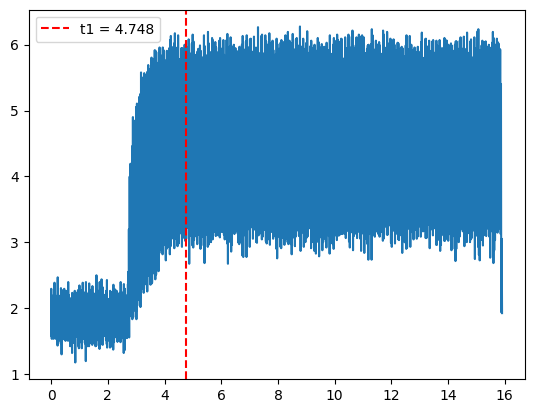

In [6]:
p = plt.plot(df['time'], df['+/Nck/!SD/nckServoDataActCurr32 [u1; 4]'])
t1_val = df['time'][idx]
plt.axvline(x=t1_val, color='r', linestyle='--', label=f't1 = {t1_val:.3f}')
plt.legend()

Step 2 — Organise your dataset structure
Each experimental run is one sample: a time-series of length NiN_i
Ni​ (spindle current) plus a fixed set of scalar cutting parameters. Store them as a list of dicts or a structured DataFrame.

In [8]:
dataset = []   # ← outside the loop, initialised once

for cut_exper_idx in range(len(cut_param)):    # or however you iterate your 64 files

    # --- load the measurement file for this cut ---
    cutting_test = data_file_path + '\\all\\' + df_info['SinuTraceFile (*.csv)'][0]
    df = pd.read_csv(cutting_test)   # adjust to your file loading logic
    
    # --- cutting parameters for this file ---
    cut_param_current_process = cut_param.iloc[cut_exper_idx]
    f      = cut_param_current_process['f (mm/min)']
    r_tool = cut_param_current_process['R (mm)']
    
    # --- compute ramp-up offset ---
    s_offset  = 5
    s_ramp_up = 2 * r_tool + s_offset
    t_ramp_up = s_ramp_up / f * 60
    
    # --- find index where actual cutting starts ---
    idx = np.argmax(df['time'] > t_ramp_up)
    
    # --- extract cutting signal only ---
    iq_eval = df["+/Nck/!SD/nckServoDataActCurr32 [u1; 4]"][idx:]
    
    # --- append this cut as one sample ---
    dataset.append({
        "signal": np.asarray(iq_eval, dtype=float),
        "ap":  float(cut_param_current_process['Ap (mm)']),
        "fz":  float(cut_param_current_process['fz']),
        "n":   float(cut_param_current_process['N (rpm)']),
        "D":   float(2 * cut_param_current_process['R (mm)']),
        "z":   float(cut_param_current_process['Z']),
        "ae":  float(cut_param_current_process['Ae (mm)']),
    })

print(f"Dataset built: {len(dataset)} samples")
for i, s in enumerate(dataset):
    print(f"  [{i:2d}]  ae={s['ae']:.2f} mm  |  signal length={len(s['signal'])}  |  n={s['n']:.0f} rpm")

Dataset built: 64 samples
  [ 0]  ae=40.00 mm  |  signal length=5281  |  n=2108 rpm
  [ 1]  ae=38.00 mm  |  signal length=5281  |  n=2108 rpm
  [ 2]  ae=32.00 mm  |  signal length=5281  |  n=2108 rpm
  [ 3]  ae=26.00 mm  |  signal length=5281  |  n=2108 rpm
  [ 4]  ae=40.00 mm  |  signal length=4740  |  n=1686 rpm
  [ 5]  ae=38.00 mm  |  signal length=4740  |  n=1686 rpm
  [ 6]  ae=32.00 mm  |  signal length=4740  |  n=1686 rpm
  [ 7]  ae=26.00 mm  |  signal length=4740  |  n=1686 rpm
  [ 8]  ae=40.00 mm  |  signal length=5645  |  n=2530 rpm
  [ 9]  ae=38.00 mm  |  signal length=5645  |  n=2530 rpm
  [10]  ae=32.00 mm  |  signal length=5645  |  n=2530 rpm
  [11]  ae=26.00 mm  |  signal length=5645  |  n=2530 rpm
  [12]  ae=40.00 mm  |  signal length=6151  |  n=2108 rpm
  [13]  ae=38.00 mm  |  signal length=6151  |  n=2108 rpm
  [14]  ae=32.00 mm  |  signal length=6151  |  n=2108 rpm
  [15]  ae=26.00 mm  |  signal length=6151  |  n=2108 rpm
  [16]  ae=40.00 mm  |  signal length=4198  | 

If all signals have the same length (e.g., one revolution resampled to 512 points), you can use a NumPy array. If lengths differ, use variable-length lists and aggregate to fixed-length features in Step 3.

Step 3 — Extract physics-informed features from the current signal
This is the most critical step. The raw time-series is too long and redundant to feed directly into an MLP. You want features that encode what the Kienzle model says should be informative about $a_e$

In [9]:
def extract_signal_features(signal: np.ndarray, n_rpm: float, fs: float) -> dict:
    """
    Extract Kienzle-relevant features from one spindle current time series.
    
    Parameters
    ----------
    signal : raw current samples [A]
    n_rpm  : spindle speed [rpm] — needed to segment by revolution
    fs     : sampling frequency [Hz]
    """
    samples_per_rev = int(fs * 60 / n_rpm)
    signal = np.asarray(signal, dtype=float)   # ← add this line
    
    # Segment into complete revolutions
    n_revs = len(signal) // samples_per_rev
    revolutions = signal[:n_revs * samples_per_rev].reshape(n_revs, samples_per_rev)
    
    # -- Statistical features (global) --
    rms       = np.sqrt(np.mean(signal**2))
    peak      = np.max(np.abs(signal))
    crest     = peak / (rms + 1e-9)
    mean_rect = np.mean(np.abs(signal))
    std       = np.std(signal)
    
    # -- Kienzle-aligned features (per-revolution torque proxy) --
    # Current ≈ torque proxy: Mc_proxy(k) = mean(|I(k)|) for revolution k
    rev_means = revolutions.mean(axis=1)
    rev_maxes = revolutions.max(axis=1)
    
    mean_rev_mean = rev_means.mean()
    mean_rev_max  = rev_maxes.mean()
    std_rev_max   = rev_maxes.std()     # captures engagement variability
    
    # -- Spectral features --
    spectrum = np.abs(np.fft.rfft(signal))
    freqs    = np.fft.rfftfreq(len(signal), d=1/fs)
    tooth_freq = n_rpm / 60 * 4        # tooth-passing frequency (adjust z)
    
    # Energy in tooth-passing band ± 50 Hz
    band_mask = (freqs >= tooth_freq - 50) & (freqs <= tooth_freq + 50)
    tooth_energy = np.sum(spectrum[band_mask]**2) / (np.sum(spectrum**2) + 1e-9)
    
    return {
        "rms": rms, "peak": peak, "crest": crest,
        "mean_rect": mean_rect, "std": std,
        "mean_rev_mean": mean_rev_mean, "mean_rev_max": mean_rev_max,
        "std_rev_max": std_rev_max, "tooth_energy": tooth_energy,
    }

Step 4 — Add the Kienzle normalisation feature
You can also compute a Kienzle-normalised torque residual — how much of the measured current remains unexplained when you divide out the known dependence on $a_p$, $f_z$ and the Kienzle exponent $m_c$​. This is a strong physics-informed engineered feature:

In [10]:
def kienzle_normalized_torque(Mc_mean: float, kc11: float, mc: float,
                               ap: float, fz: float, D: float) -> float:
    """
    Normalise measured mean torque by the Kienzle theoretical prediction.
    The residual carries information about ae (radial engagement).
    
    Mc_kienzle = kc11 * ap * fz^(1 - mc) * (D/2)    [simplified]
    """
    Mc_kienzle = kc11 * ap * (fz ** (1.0 - mc)) * (D / 2.0)
    return Mc_mean / (Mc_kienzle + 1e-9)   # ratio ≈ f(ae)

Use nominal values of $k_{c1.1}$ and $m_c$ from your material database here; the MLP will learn the residual mapping from this normalised quantity to $a_e$​.

Step 5 — Build the full feature vector

In [11]:
def build_feature_vector(sample: dict, kc11: float, mc: float, fs: float) -> np.ndarray:
    sig_feats = extract_signal_features(
        sample["signal"], sample["n"], fs
    )
    
    Mc_norm = kienzle_normalized_torque(
        sig_feats["mean_rev_max"],
        kc11, mc,
        sample["ap"], sample["fz"], sample["D"]
    )
    
    process_feats = np.array([
        sample["ap"],
        sample["fz"],
        sample["n"],
        sample["D"],
        sample["z"],
    ])
    
    signal_feats = np.array([
        sig_feats["rms"],
        sig_feats["peak"],
        sig_feats["crest"],
        sig_feats["mean_rev_mean"],
        sig_feats["mean_rev_max"],
        sig_feats["std_rev_max"],
        sig_feats["tooth_energy"],
        Mc_norm,
    ])
    
    return np.concatenate([signal_feats, process_feats])  # shape (13,)

Step 6 — Assemble the dataset and scale


Scaling y as well is important here because it allows you to use a default learning rate and makes the loss numerically stable.

In [12]:
KC11_NOMINAL = 2300.0    # [N/mm²] — adjust to your workpiece material
MC_NOMINAL   = 0.2      # [-]
FS           = 500.0    # [Hz] — your sampling frequency

X = np.array([build_feature_vector(s, KC11_NOMINAL, MC_NOMINAL, FS) for s in dataset])
y = np.array([s["ae"] for s in dataset])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)
y_train_sc = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_sc  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

Test to see how the input to the MLP model looks like!

In [13]:
print("=== Dataset shapes ===")
print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"X_train : {X_train_sc.shape}  |  X_test : {X_test_sc.shape}")

print("\n=== Target ae [mm] ===")
print(f"min={y.min():.3f}  max={y.max():.3f}  mean={y.mean():.3f}  std={y.std():.3f}")
print(f"unique values: {np.unique(y)}")

print("\n=== Feature matrix (unscaled) ===")
feature_names = [
    "rms", "peak", "crest", "mean_rect", "std",
    "mean_rev_mean", "mean_rev_max", "std_rev_max", "tooth_energy",
    "Mc_norm",
    "ap", "fz", "n", "D", "z"
]
df_X = pd.DataFrame(X, columns=feature_names[:X.shape[1]])
print(df_X.describe().round(4))

print("\n=== NaN / Inf check ===")
print(f"NaNs in X : {np.isnan(X).sum()}")
print(f"Infs in X : {np.isinf(X).sum()}")
print(f"NaNs in y : {np.isnan(y).sum()}")

print("\n=== Scaled feature stats (sanity check — should be ~mean=0, std=1) ===")
print(f"X_train_sc  mean: {X_train_sc.mean(axis=0).round(3)}")
print(f"X_train_sc  std : {X_train_sc.std(axis=0).round(3)}")

=== Dataset shapes ===
X shape : (64, 13)
y shape : (64,)
X_train : (51, 13)  |  X_test : (13, 13)

=== Target ae [mm] ===
min=26.000  max=40.000  mean=34.000  std=5.477
unique values: [26. 32. 38. 40.]

=== Feature matrix (unscaled) ===
           rms     peak    crest  mean_rect      std  mean_rev_mean  \
count  64.0000  64.0000  64.0000    64.0000  64.0000        64.0000   
mean    5.0292   6.7778   1.3477     4.9669   6.2639         0.2278   
std     0.0234   0.0000   0.0064     0.0284   0.0359         0.0436   
min     4.9425   6.7778   1.3441     4.8625   6.1566         0.1571   
25%     5.0309   6.7778   1.3451     4.9700   6.2663         0.2054   
50%     5.0358   6.7778   1.3459     4.9743   6.2730         0.2361   
75%     5.0390   6.7778   1.3472     4.9772   6.2822         0.2384   
max     5.0428   6.7778   1.3713     4.9862   6.3112         0.3312   

       mean_rev_max  std_rev_max  tooth_energy  Mc_norm         ap    fz     n  
count       64.0000      64.0000       64

Step 7 — Define the MLP

In [14]:
class AeEstimatorMLP(nn.Module):
    def __init__(self, n_features: int, hidden: list[int] = [64, 32], dropout: float = 0.2):
        super().__init__()
        layers = []
        in_dim = n_features
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x).squeeze(-1)

n_features = X_train_sc.shape[1]
model = AeEstimatorMLP(n_features=n_features, hidden=[64, 32], dropout=0.2)
print(model)

AeEstimatorMLP(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


Start with [64, 32]. At the test stage with limited data, this depth/width is already sufficient to overfit, which is a useful diagnostic.

Step 8 — Training loop with diagnostic output

Epoch   50 | train loss 0.4706 | val loss 0.6988
Epoch  100 | train loss 0.4121 | val loss 0.6857
Epoch  150 | train loss 0.4511 | val loss 0.6628
Epoch  200 | train loss 0.4710 | val loss 0.7140
Epoch  250 | train loss 0.4742 | val loss 0.6911
Epoch  300 | train loss 0.4886 | val loss 0.7234


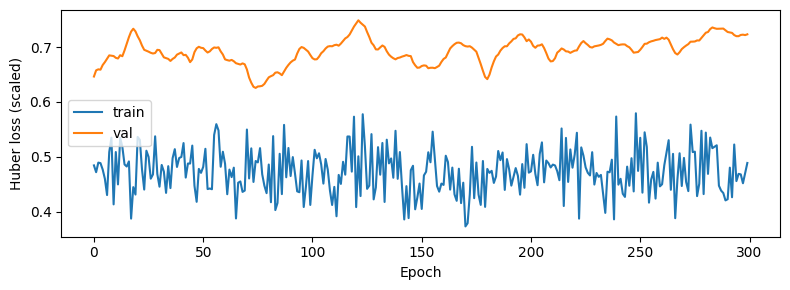

In [15]:
class MillingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(MillingDataset(X_train_sc, y_train_sc),
                          batch_size=16, shuffle=True)
val_loader   = DataLoader(MillingDataset(X_test_sc,  y_test_sc),
                          batch_size=len(X_test_sc))

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.HuberLoss(delta=1.0)   # more robust than MSE for small datasets

train_losses, val_losses = [], []

EPOCHS = 300
for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for X_b, y_b in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))
    
    model.eval()
    with torch.no_grad():
        for X_v, y_v in val_loader:
            val_loss = criterion(model(X_v), y_v).item()
    val_losses.append(val_loss)
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:4d} | train loss {train_losses[-1]:.4f} | val loss {val_losses[-1]:.4f}")

# Plot learning curves
plt.figure(figsize=(8, 3))
plt.plot(train_losses, label="train")
plt.plot(val_losses,   label="val")
plt.xlabel("Epoch"); plt.ylabel("Huber loss (scaled)")
plt.legend(); plt.tight_layout(); plt.show()

Diagnostic checkpoint: if the gap between train and val loss is large from the first few epochs, you either have too few samples or your feature vector is leaking the target. Check the data split.

Step 9 — Evaluation and back-transformation

MAE  = 6.4171 mm
RMSE = 6.7109 mm
R²   = -8.7080


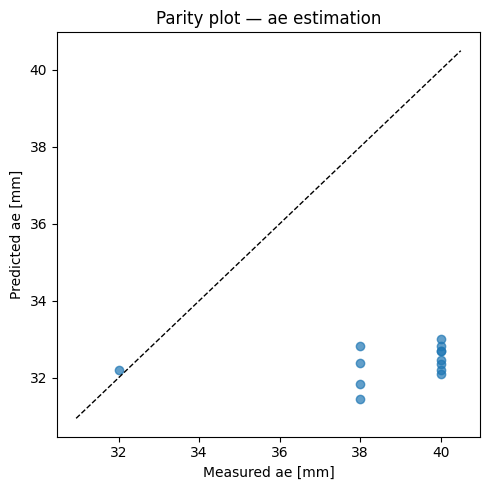

In [16]:
model.eval()
with torch.no_grad():
    y_pred_sc = model(torch.tensor(X_test_sc, dtype=torch.float32)).numpy()

y_pred = scaler_y.inverse_transform(y_pred_sc.reshape(-1, 1)).ravel()

mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(np.mean((y_test - y_pred)**2))

print(f"MAE  = {mae:.4f} mm")
print(f"RMSE = {rmse:.4f} mm")
print(f"R²   = {r2:.4f}")

# Parity plot
plt.figure(figsize=(5, 5))
lims = [min(y_test.min(), y_pred.min()) - 0.5,
        max(y_test.max(), y_pred.max()) + 0.5]
plt.plot(lims, lims, 'k--', lw=1)
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Measured ae [mm]")
plt.ylabel("Predicted ae [mm]")
plt.title("Parity plot — ae estimation")
plt.tight_layout(); plt.show()

Step 10 — Uncertainty estimation with MC Dropout (recommended for test stage)
Since you're still in a test stage, add Monte Carlo Dropout predictions before investing in more data. This gives you a rough posterior on $hat{a}_e$​ for free:

In [17]:
def mc_predict(model, x_tensor, n_samples=200):
    model.train()  # keep dropout active at inference time
    preds = np.array([
        model(x_tensor).detach().numpy()
        for _ in range(n_samples)
    ])
    model.eval()
    mean_sc = preds.mean(axis=0)
    std_sc  = preds.std(axis=0)
    mean = scaler_y.inverse_transform(mean_sc.reshape(-1, 1)).ravel()
    # propagate std through inverse scaler (affine, so just divide by scale)
    std  = std_sc / scaler_y.scale_[0]
    return mean, std

x_test_t = torch.tensor(X_test_sc, dtype=torch.float32)
ae_mean, ae_std = mc_predict(model, x_test_t)

for i in range(len(y_test)):
    print(f"True ae={y_test[i]:.2f}  |  Predicted {ae_mean[i]:.2f} ± {ae_std[i]:.3f} mm")

True ae=40.00  |  Predicted 32.38 ± 0.003 mm
True ae=32.00  |  Predicted 32.23 ± 0.004 mm
True ae=40.00  |  Predicted 32.84 ± 0.005 mm
True ae=40.00  |  Predicted 32.72 ± 0.005 mm
True ae=38.00  |  Predicted 31.53 ± 0.014 mm
True ae=40.00  |  Predicted 32.72 ± 0.006 mm
True ae=40.00  |  Predicted 33.02 ± 0.013 mm
True ae=40.00  |  Predicted 32.07 ± 0.012 mm
True ae=38.00  |  Predicted 32.38 ± 0.008 mm
True ae=38.00  |  Predicted 32.84 ± 0.005 mm
True ae=40.00  |  Predicted 32.23 ± 0.004 mm
True ae=38.00  |  Predicted 31.86 ± 0.009 mm
True ae=40.00  |  Predicted 32.50 ± 0.003 mm


| Decision | Rationale |
|----------|-----------|
| Feature extraction rather than raw signal input | Signals can be thousands of points long; a direct MLP on raw $I(t)$ would overfit severely at small $n$ |
| Per-revolution maximum torque as a feature | Directly motivated by Kienzle: peak chip thickness per revolution is the dominant driver of peak torque |
| Kienzle-normalised residual | Removes known variation due to $a_p$, $f_z$; isolates the $a_e$-dependent signal |
| Huber loss | More robust than MSE when you have outlier cuts (chatter, tool runout) |
| Scaling $y$ | Prevents Adam from behaving erratically when the target has physical units of order 1–10 mm |
| MC Dropout for uncertainty | Zero-overhead first estimate of prediction confidence; important before claiming the model generalises |

Once this test-stage pipeline is stable, the natural next step is replacing the hand-crafted feature extractor with a 1-D CNN or a small temporal network (TCN) that learns the feature mapping from data — but only once you have enough labelled cuts to justify it (typically >200 ae​ settings).